# Proyecto final - Sistemas de Recomendación Inteligente
## Sistema de recomendación con Surprise

**Alumno:** Gerardo Hernández Chávez  
**Programa:** Máster en Data Science y Big Data  
**Módulo:** Sistemas de Recomendación Inteligente  
**Entrega:** Proyecto final

## 1. Objetivo

El notebook replica el ejercicio base propuesto con Surprise sobre `ratings.dat` y desarrolla una versión propia más completa. Se cargan y exploran los ratings, se entrenan modelos colaborativos, se comparan RMSE y MAE, se valida su estabilidad y se genera un Top N para un usuario existente.

## 2. Instalación para Google Colab

Las líneas están comentadas para no reinstalar dependencias cuando el entorno ya está preparado. En Colab deben descomentarse y ejecutarse antes de las importaciones.

In [1]:
# Instalación recomendada para Google Colab.
# Ejecutar solo si Surprise no está instalado en el entorno.
# !pip install numpy==1.26.4
# !pip install scikit-surprise==1.1.3 --no-binary scikit-surprise

## 3. Importación de librerías

In [2]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from surprise import (
    BaselineOnly,
    Dataset,
    KNNBasic,
    KNNBaseline,
    KNNWithMeans,
    Reader,
    SVD,
    accuracy,
)
from surprise.model_selection import GridSearchCV, cross_validate, train_test_split

SEMILLA = 42
np.random.seed(SEMILLA)
pd.set_option("display.precision", 4)
plt.style.use("ggplot")

## 4. Localización y lectura de `ratings.dat`

El archivo disponible corresponde a MovieLens 1M. Cada línea sigue el formato `user_id::item_id::rating::timestamp`. La búsqueda admite el nombre esperado `ratings.dat`, el nombre local `ratings (1).dat` y la ruta habitual de Colab.

In [3]:
RUTA_CLASE_4 = Path(
    "/Users/gerardo/Desktop/mi_proyecto/Cursos/Master IEBS - Ciencia de Datos/"
    "14. Sistemas de Recomendación Inteligente/Clase 4"
)

candidatos = [
    Path("/content/ratings.dat"),
    Path("/content/ratings (1).dat"),
    Path("ratings.dat"),
    Path("ratings (1).dat"),
    RUTA_CLASE_4 / "ratings.dat",
    RUTA_CLASE_4 / "ratings (1).dat",
]
ratings_path = next((ruta for ruta in candidatos if ruta.exists()), None)

if ratings_path is None:
    raise FileNotFoundError(
        "No se encontró ratings.dat. En Colab, carga el archivo en /content."
    )

with ratings_path.open("r", encoding="utf-8") as archivo:
    primera_linea = archivo.readline().strip()

separador = "::" if "::" in primera_linea else ","
print(f"Archivo: {ratings_path}")
print(f"Separador detectado: {separador!r}")
print(f"Primera línea: {primera_linea}")

Archivo: ratings (1).dat
Separador detectado: '::'
Primera línea: 1::1193::5::978300760


In [4]:
columnas = ["user_id", "item_id", "rating", "timestamp"]
ratings = pd.read_csv(
    ratings_path,
    sep=separador,
    engine="python",
    names=columnas,
)

display(ratings.head())
print(f"Dimensiones: {ratings.shape[0]:,} filas x {ratings.shape[1]} columnas")

,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


Dimensiones: 1,000,209 filas x 4 columnas


### 4.1 Calidad y estructura de los datos

In [5]:
resumen_calidad = pd.DataFrame(
    {
        "tipo": ratings.dtypes.astype(str),
        "nulos": ratings.isna().sum(),
        "valores_unicos": ratings.nunique(),
    }
)

resumen_dataset = pd.DataFrame(
    {
        "medida": [
            "ratings",
            "usuarios únicos",
            "ítems únicos",
            "rating mínimo",
            "rating máximo",
            "nulos totales",
        ],
        "valor": [
            len(ratings),
            ratings["user_id"].nunique(),
            ratings["item_id"].nunique(),
            ratings["rating"].min(),
            ratings["rating"].max(),
            ratings.isna().sum().sum(),
        ],
    }
)

display(resumen_calidad)
display(resumen_dataset)

,tipo,nulos,valores_unicos
user_id,int64,0,6040
item_id,int64,0,3706
rating,int64,0,5
timestamp,int64,0,458455


,medida,valor
0,ratings,1000209
1,usuarios únicos,6040
2,ítems únicos,3706
3,rating mínimo,1
4,rating máximo,5
5,nulos totales,0


### 4.2 Distribución de ratings

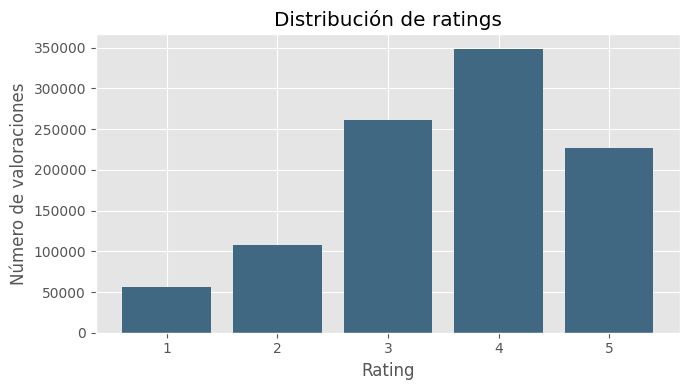

,cantidad
rating,
1,56174
2,107557
3,261197
4,348971
5,226310


In [6]:
distribucion_ratings = ratings["rating"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(distribucion_ratings.index.astype(str), distribucion_ratings.values, color="#406882")
ax.set_title("Distribución de ratings")
ax.set_xlabel("Rating")
ax.set_ylabel("Número de valoraciones")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

display(distribucion_ratings.rename("cantidad").to_frame())

### 4.3 Usuarios e ítems con más valoraciones

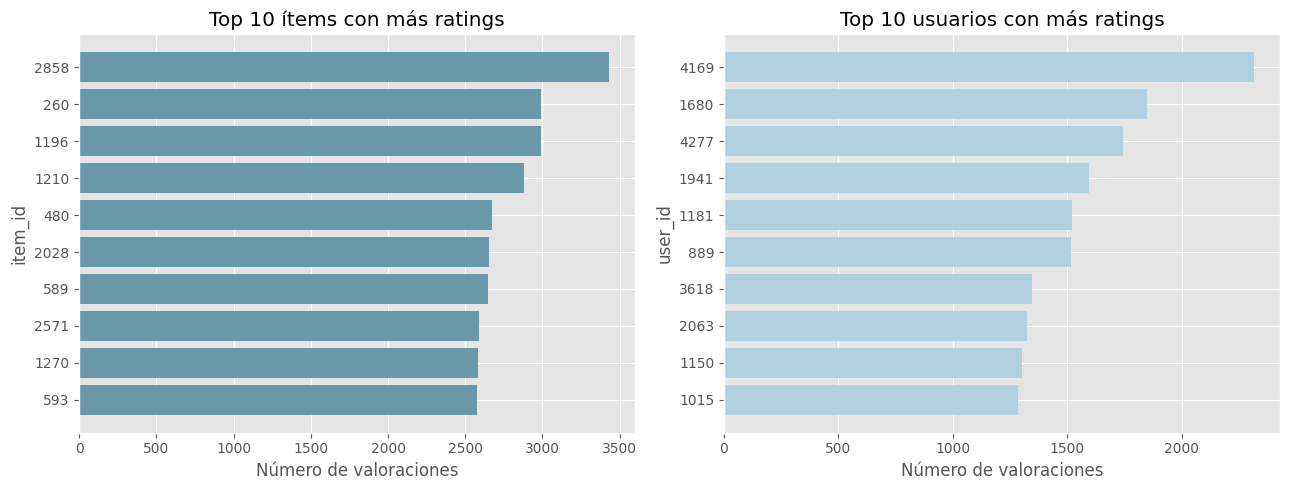

In [7]:
top_items = ratings["item_id"].value_counts().head(10).sort_values()
top_usuarios = ratings["user_id"].value_counts().head(10).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(top_items.index.astype(str), top_items.values, color="#6998AB")
axes[0].set_title("Top 10 ítems con más ratings")
axes[0].set_xlabel("Número de valoraciones")
axes[0].set_ylabel("item_id")

axes[1].barh(top_usuarios.index.astype(str), top_usuarios.values, color="#B1D0E0")
axes[1].set_title("Top 10 usuarios con más ratings")
axes[1].set_xlabel("Número de valoraciones")
axes[1].set_ylabel("user_id")

plt.tight_layout()
plt.show()

**Lectura inicial.** El archivo contiene más de un millón de valoraciones explícitas y no presenta nulos. La actividad está concentrada: algunos usuarios e ítems acumulan muchas más observaciones que el resto. Esta desigualdad importa porque los modelos aprenden mejor sobre entidades con suficiente historial y tienen más incertidumbre en zonas poco observadas.

## 5. Preparación del dataset para Surprise

`Reader` declara el orden y el separador del archivo. Para el trabajo posterior también se crea un objeto desde el DataFrame, lo que permite reutilizar las mismas filas en validación cruzada y búsqueda de hiperparámetros.

In [8]:
escala_rating = (float(ratings["rating"].min()), float(ratings["rating"].max()))
reader_archivo = Reader(
    line_format="user item rating timestamp",
    sep=separador,
    rating_scale=escala_rating,
)
data_archivo = Dataset.load_from_file(str(ratings_path), reader=reader_archivo)

reader_df = Reader(rating_scale=escala_rating)
data = Dataset.load_from_df(
    ratings[["user_id", "item_id", "rating"]],
    reader_df,
)
trainset, testset = train_test_split(
    data_archivo,
    test_size=0.30,
    random_state=SEMILLA,
)

print(f"Escala de rating: {escala_rating}")
print(f"Ratings de entrenamiento: {trainset.n_ratings:,}")
print(f"Ratings de prueba: {len(testset):,}")

Escala de rating: (1.0, 5.0)
Ratings de entrenamiento: 700,146
Ratings de prueba: 300,063


## 6. Parte 1 — Réplica del ejercicio propuesto

Se respetan los dos enfoques del recurso base:

- `KNNBasic`: 50 vecinos, similitud de Pearson y búsqueda de usuarios parecidos.
- `KNNWithMeans`: 50 vecinos, similitud coseno y búsqueda de ítems parecidos, ajustando por la media de ratings.

Se añade `random_state` en la partición y también se calcula MAE para completar la interpretación.

In [9]:
modelos_replica = {
    "KNNBasic usuario-usuario": KNNBasic(
        k=50,
        sim_options={"name": "pearson", "user_based": True},
        verbose=False,
    ),
    "KNNWithMeans ítem-ítem": KNNWithMeans(
        k=50,
        sim_options={"name": "cosine", "user_based": False},
        verbose=False,
    ),
}

tiempos_entrenamiento = {}
for nombre, modelo in modelos_replica.items():
    inicio = time.perf_counter()
    modelo.fit(trainset)
    tiempos_entrenamiento[nombre] = time.perf_counter() - inicio
    print(f"{nombre}: entrenamiento completado en {tiempos_entrenamiento[nombre]:.2f} s")

KNNBasic usuario-usuario: entrenamiento completado en 26.42 s


KNNWithMeans ítem-ítem: entrenamiento completado en 5.12 s


In [10]:
user_id = "42"
item_id = "7"

predicciones_manuales = pd.DataFrame(
    [
        {
            "modelo": nombre,
            "user_id": user_id,
            "item_id": item_id,
            "rating_estimado": modelo.predict(user_id, item_id).est,
        }
        for nombre, modelo in modelos_replica.items()
    ]
)

display(predicciones_manuales)

,modelo,user_id,item_id,rating_estimado
0,KNNBasic usuario-usuario,42,7,3.4472
1,KNNWithMeans ítem-ítem,42,7,3.7044


In [11]:
resultados_holdout = []
predicciones_holdout = {}

for nombre, modelo in modelos_replica.items():
    inicio = time.perf_counter()
    predicciones = modelo.test(testset)
    tiempo_prueba = time.perf_counter() - inicio
    predicciones_holdout[nombre] = predicciones
    resultados_holdout.append(
        {
            "modelo": nombre,
            "RMSE": accuracy.rmse(predicciones, verbose=False),
            "MAE": accuracy.mae(predicciones, verbose=False),
            "entrenamiento_s": tiempos_entrenamiento[nombre],
            "prueba_s": tiempo_prueba,
        }
    )

comparacion_replica = pd.DataFrame(resultados_holdout).sort_values("RMSE")
display(comparacion_replica)

,modelo,RMSE,MAE,entrenamiento_s,prueba_s
1,KNNWithMeans ítem-ítem,0.8975,0.7052,5.1225,30.2249
0,KNNBasic usuario-usuario,0.9643,0.7678,26.4242,61.6533


In [12]:
mejor_replica_rmse = comparacion_replica.nsmallest(1, "RMSE").iloc[0]
mejor_replica_mae = comparacion_replica.nsmallest(1, "MAE").iloc[0]

print(
    f"Menor RMSE en la réplica: {mejor_replica_rmse['modelo']} "
    f"({mejor_replica_rmse['RMSE']:.4f})."
)
print(
    f"Menor MAE en la réplica: {mejor_replica_mae['modelo']} "
    f"({mejor_replica_mae['MAE']:.4f})."
)
print(
    "RMSE penaliza más los errores grandes; MAE expresa el desvío absoluto medio "
    "en puntos de rating."
)

Menor RMSE en la réplica: KNNWithMeans ítem-ítem (0.8975).
Menor MAE en la réplica: KNNWithMeans ítem-ítem (0.7052).
RMSE penaliza más los errores grandes; MAE expresa el desvío absoluto medio en puntos de rating.


## 7. Parte 2 — Implementación propia con Surprise

La ampliación conserva los resultados de la réplica y agrega dos referencias complementarias: `SVD`, que aprende factores latentes, y `BaselineOnly`, que modela la media global y los sesgos de usuarios e ítems. Todos se evalúan sobre la misma partición para que la comparación sea válida.

In [13]:
modelos_adicionales = {
    "SVD": SVD(
        n_factors=100,
        n_epochs=20,
        lr_all=0.005,
        reg_all=0.02,
        random_state=SEMILLA,
    ),
    "BaselineOnly": BaselineOnly(verbose=False),
}

for nombre, modelo in modelos_adicionales.items():
    inicio = time.perf_counter()
    modelo.fit(trainset)
    tiempo_entrenamiento = time.perf_counter() - inicio

    inicio = time.perf_counter()
    predicciones = modelo.test(testset)
    tiempo_prueba = time.perf_counter() - inicio
    predicciones_holdout[nombre] = predicciones
    resultados_holdout.append(
        {
            "modelo": nombre,
            "RMSE": accuracy.rmse(predicciones, verbose=False),
            "MAE": accuracy.mae(predicciones, verbose=False),
            "entrenamiento_s": tiempo_entrenamiento,
            "prueba_s": tiempo_prueba,
        }
    )

comparacion_modelos = (
    pd.DataFrame(resultados_holdout)
    .drop_duplicates(subset="modelo", keep="last")
    .sort_values("RMSE")
    .reset_index(drop=True)
)
comparacion_modelos["comentario"] = comparacion_modelos["modelo"].map(
    {
        "KNNBasic usuario-usuario": "Vecinos de usuarios con Pearson",
        "KNNWithMeans ítem-ítem": "Vecinos de ítems ajustados por media",
        "SVD": "Factores latentes",
        "BaselineOnly": "Referencia basada en sesgos",
    }
)

display(comparacion_modelos)

,modelo,RMSE,MAE,entrenamiento_s,prueba_s,comentario
0,SVD,0.8817,0.6922,4.2285,1.1420,Factores latentes
1,KNNWithMeans ítem-ítem,0.8975,0.7052,5.1225,30.2249,Vecinos de ítems ajustados por media
2,BaselineOnly,0.9096,0.7198,0.6970,0.7878,Referencia basada en sesgos
3,KNNBasic usuario-usuario,0.9643,0.7678,26.4242,61.6533,Vecinos de usuarios con Pearson


In [14]:
mejor_rmse = comparacion_modelos.nsmallest(1, "RMSE").iloc[0]
mejor_mae = comparacion_modelos.nsmallest(1, "MAE").iloc[0]

print(f"Mejor RMSE: {mejor_rmse['modelo']} ({mejor_rmse['RMSE']:.4f})")
print(f"Mejor MAE: {mejor_mae['modelo']} ({mejor_mae['MAE']:.4f})")
print(
    "La diferencia entre modelos debe leerse junto con el costo de entrenamiento, "
    "la cobertura y el objetivo de negocio."
)

Mejor RMSE: SVD (0.8817)
Mejor MAE: SVD (0.6922)
La diferencia entre modelos debe leerse junto con el costo de entrenamiento, la cobertura y el objetivo de negocio.


## 8. Validación cruzada

Para mantener una ejecución razonable en Colab, la validación se realiza sobre una muestra reproducible de 120 000 ratings de los 750 usuarios más activos. Este recorte acelera KNN, pero introduce un sesgo hacia usuarios con más historial; por ello sus valores sirven como comprobación complementaria y no sustituyen la evaluación *holdout* sobre el dataset completo.

In [15]:
usuarios_activos_cv = ratings["user_id"].value_counts().head(750).index
ratings_cv = ratings[ratings["user_id"].isin(usuarios_activos_cv)]
ratings_cv = ratings_cv.sample(
    n=min(120_000, len(ratings_cv)),
    random_state=SEMILLA,
)
data_cv = Dataset.load_from_df(
    ratings_cv[["user_id", "item_id", "rating"]],
    reader_df,
)

print(f"Ratings para validación cruzada: {len(ratings_cv):,}")
print(f"Usuarios en la muestra: {ratings_cv['user_id'].nunique():,}")
print(f"Ítems en la muestra: {ratings_cv['item_id'].nunique():,}")

Ratings para validación cruzada: 120,000
Usuarios en la muestra: 750
Ítems en la muestra: 3,418


In [16]:
modelos_cv = {
    "SVD": SVD(n_factors=50, n_epochs=15, random_state=SEMILLA),
    "KNNBasic": KNNBasic(
        k=40,
        sim_options={"name": "pearson", "user_based": True},
        verbose=False,
    ),
}

resultados_cv = []
for nombre, modelo in modelos_cv.items():
    resultado = cross_validate(
        modelo,
        data_cv,
        measures=["RMSE", "MAE"],
        cv=3,
        verbose=False,
        n_jobs=1,
    )
    resultados_cv.append(
        {
            "modelo": nombre,
            "RMSE_promedio": np.mean(resultado["test_rmse"]),
            "RMSE_std": np.std(resultado["test_rmse"]),
            "MAE_promedio": np.mean(resultado["test_mae"]),
            "MAE_std": np.std(resultado["test_mae"]),
            "fit_s_promedio": np.mean(resultado["fit_time"]),
        }
    )

comparacion_cv = pd.DataFrame(resultados_cv).sort_values("RMSE_promedio")
display(comparacion_cv)

,modelo,RMSE_promedio,RMSE_std,MAE_promedio,MAE_std,fit_s_promedio
0,SVD,0.9188,0.0007,0.7288,0.0009,0.3124
1,KNNBasic,1.0013,0.0029,0.7977,0.0014,0.1301


## 9. Búsqueda moderada de hiperparámetros

Se prueban ocho configuraciones de SVD con tres particiones. El espacio es pequeño a propósito: permite observar el efecto de épocas, tasa de aprendizaje y regularización sin convertir el notebook en una búsqueda costosa.

In [17]:
param_grid = {
    "n_epochs": [10, 20],
    "lr_all": [0.002, 0.005],
    "reg_all": [0.02, 0.10],
}

grid_svd = GridSearchCV(
    SVD,
    param_grid,
    measures=["rmse", "mae"],
    cv=3,
    n_jobs=1,
    joblib_verbose=0,
)
grid_svd.fit(data_cv)

print(f"Mejor RMSE promedio: {grid_svd.best_score['rmse']:.4f}")
print(f"Parámetros para RMSE: {grid_svd.best_params['rmse']}")
print(f"Mejor MAE promedio: {grid_svd.best_score['mae']:.4f}")
print(f"Parámetros para MAE: {grid_svd.best_params['mae']}")

Mejor RMSE promedio: 0.9136
Parámetros para RMSE: {'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.1}
Mejor MAE promedio: 0.7266
Parámetros para MAE: {'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.1}


## 10. Generación de recomendaciones Top N

Predecir un rating aislado no es todavía recomendar. La función identifica los ítems que el usuario no calificó, estima cada rating y devuelve los resultados mejor puntuados. El modelo ajustado se reentrena con todos los datos antes de producir el Top 10.

In [18]:
def recomendar_items(modelo, user_id, ratings_df, top_n=10):
    "Genera un Top N entre los ítems que el usuario todavía no calificó."
    user_id = int(user_id)
    usuarios_disponibles = set(ratings_df["user_id"].unique())
    if user_id not in usuarios_disponibles:
        raise ValueError(
            "El usuario no existe en el historial; se requiere una estrategia de cold-start."
        )

    items_calificados = set(
        ratings_df.loc[ratings_df["user_id"] == user_id, "item_id"]
    )
    items_disponibles = set(ratings_df["item_id"].unique())
    items_no_calificados = items_disponibles - items_calificados

    recomendaciones = [
        {
            "user_id": user_id,
            "item_id": item_id,
            "rating_estimado": modelo.predict(user_id, item_id).est,
        }
        for item_id in items_no_calificados
    ]

    return (
        pd.DataFrame(recomendaciones)
        .sort_values("rating_estimado", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

In [19]:
mejores_parametros = grid_svd.best_params["rmse"]
modelo_final = SVD(**mejores_parametros, random_state=SEMILLA)
modelo_final.fit(data.build_full_trainset())

usuario_objetivo = 42
top_recomendaciones = recomendar_items(
    modelo=modelo_final,
    user_id=usuario_objetivo,
    ratings_df=ratings,
    top_n=10,
)

display(top_recomendaciones)

,user_id,item_id,rating_estimado
0,42,2905,4.6752
1,42,3338,4.5267
2,42,745,4.5227
3,42,1148,4.4961
4,42,2762,4.4614
5,42,2019,4.4455
6,42,904,4.4410
7,42,50,4.4394
8,42,1262,4.4278
9,42,922,4.4119


## 11. Interpretación y limitaciones

RMSE y MAE miden la precisión de ratings, pero no garantizan por sí solos una buena lista. Un recomendador útil también debe revisar relevancia en las primeras posiciones, cobertura, diversidad, novedad y respuesta real del usuario.

Las principales limitaciones son:

- **Cold-start de usuario:** sin historial no se puede inferir un perfil colaborativo fiable.
- **Cold-start de ítem:** un ítem sin ratings no aparece en patrones de similitud o factores latentes.
- **Sparsity:** cada usuario observa una fracción pequeña del catálogo.
- **Ratings explícitos:** Surprise se concentra en calificaciones y no incorpora clics o reproducciones de forma nativa.
- **Actualización:** los patrones cambian y requieren reentrenamiento y seguimiento periódico.

La comparación *holdout* es la referencia principal de este notebook. La validación y el grid reducido sirven para comprobar estabilidad y explorar parámetros con un costo apropiado para Colab.

## 12. Conclusión

Se replicó el ejercicio base con `KNNBasic` y `KNNWithMeans`, se incorporaron SVD y un baseline, y se compararon los modelos mediante RMSE y MAE. También se aplicaron validación cruzada, una búsqueda moderada de hiperparámetros y una función Top N sobre ítems no calificados. Surprise resulta útil para prototipar recomendadores basados en ratings con una API clara. Un sistema real necesitaría más señales, metadatos, métricas de ranking y negocio, monitoreo, manejo de nuevos usuarios e ítems y actualización periódica.